In [2]:
import matplotlib.pyplot as plt
import pandas as pd

titanic = pd.read_csv('../data/titanic.csv')
titanic.age = pd.to_numeric(titanic.age, errors='coerce')
houses = pd.read_csv('../data/kc_house_data.csv')
ufos = pd.read_csv('../data/nuforc_reports.csv', parse_dates=['date_time', 'posted'])

<Axes: >

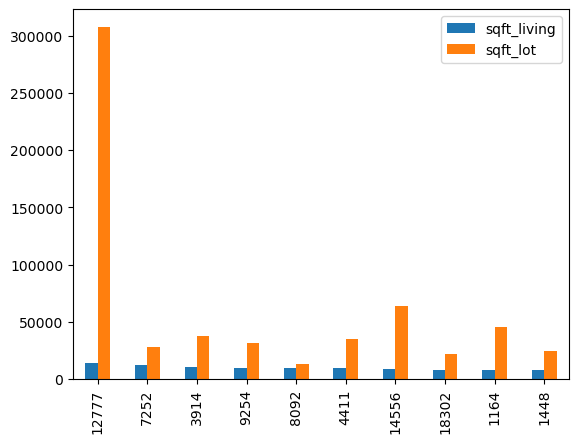

In [7]:
#plot on DF plotes for every column(Series)
to_plot = houses[['sqft_living', 'sqft_lot']].sort_values('sqft_living', ascending=False).head(10)
to_plot.plot(kind='bar')

<Axes: >

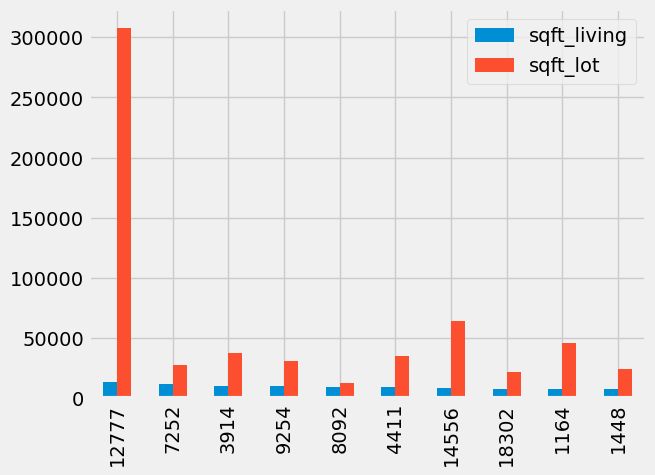

In [9]:
#Styles
plt.style.available
plt.style.use('fivethirtyeight')
to_plot.plot(kind='bar')

<Axes: title={'center': 'Sex Brakdown on Titanic'}, xlabel='sex'>

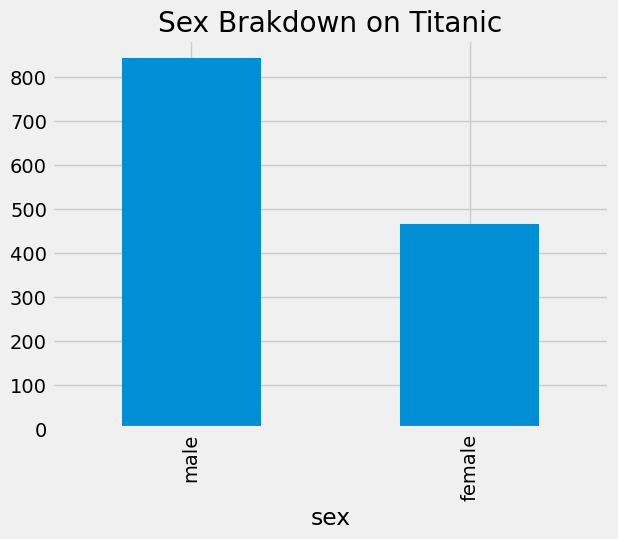

In [12]:
titanic.sex.value_counts().plot(kind='bar', title='Sex Brakdown on Titanic')

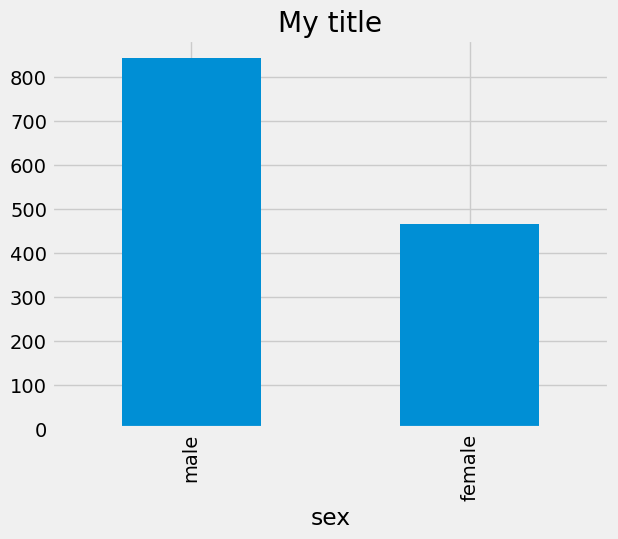

In [13]:
titanic.sex.value_counts().plot(kind='bar')
plt.title('My title')
plt.show()

In [15]:
ufos['month'] = ufos['date_time'].dt.month
months = ufos['month'].value_counts()

<Axes: title={'center': 'UFO Sightings By Month'}, xlabel='month'>

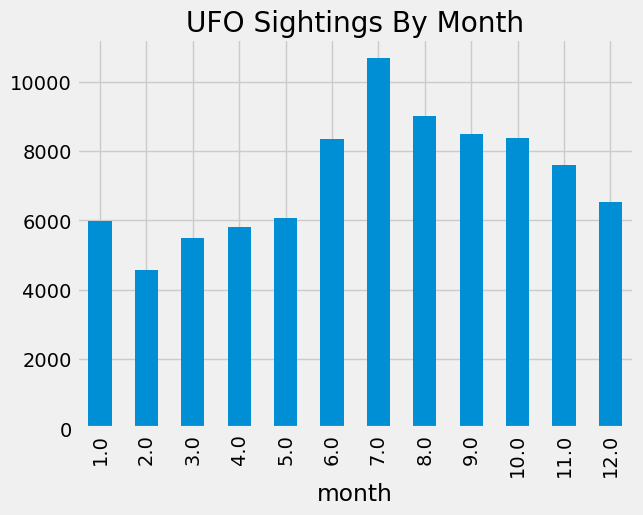

In [18]:
sightings = months.sort_index()
sightings.plot(kind='bar', title='UFO Sightings By Month')
#Less control when pandas is used fontsize affects xticks and y ticks and not the title

<Axes: title={'center': 'UFO Sightings By Month'}, xlabel='month'>

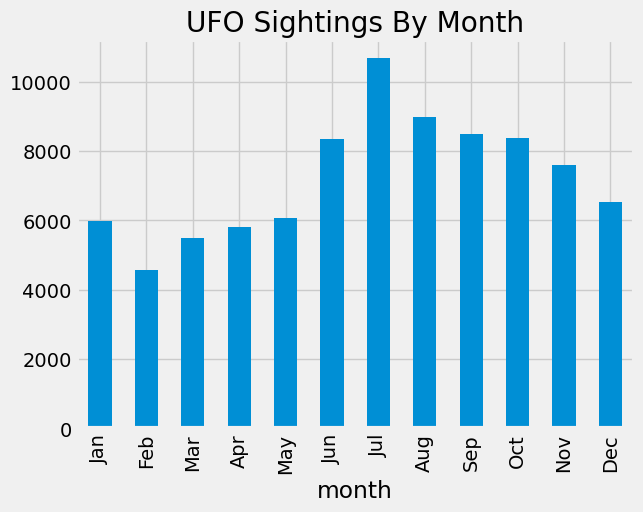

In [20]:
months_dict = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec",
}
rn_sightings = sightings.rename(months_dict)
rn_sightings.plot(kind='bar', title='UFO Sightings By Month')

In [23]:
salaries = pd.read_csv('../data/Salaries.csv', low_memory=False)
salaries['BasePay'] = pd.to_numeric(salaries['BasePay'], errors='coerce').fillna(0)
salaries['OvertimePay'] = pd.to_numeric(salaries['OvertimePay'], errors='coerce').fillna(0)
salaries['OtherPay'] = pd.to_numeric(salaries['OtherPay'], errors='coerce').fillna(0)

In [25]:
df = salaries[['EmployeeName', 'BasePay', 'OvertimePay', 'OtherPay']]
df.set_index('EmployeeName', inplace=True)

<Axes: xlabel='EmployeeName'>

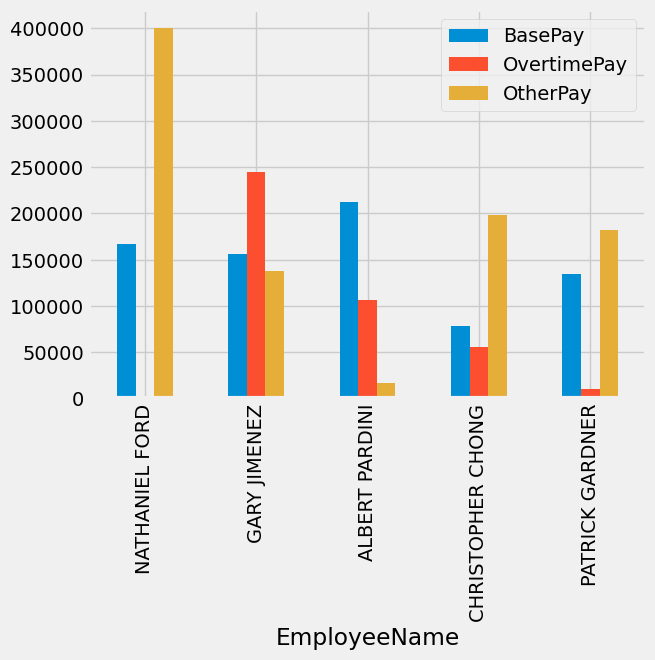

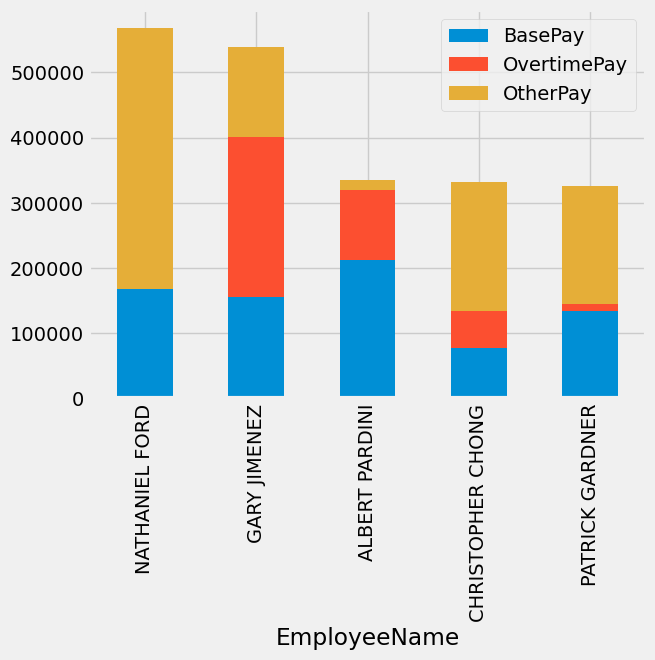

In [27]:
df.head().plot(kind='bar')
df.head().plot(kind='bar', stacked=True)

<Axes: title={'center': 'Highest Paid Employees'}, ylabel='EmployeeName'>

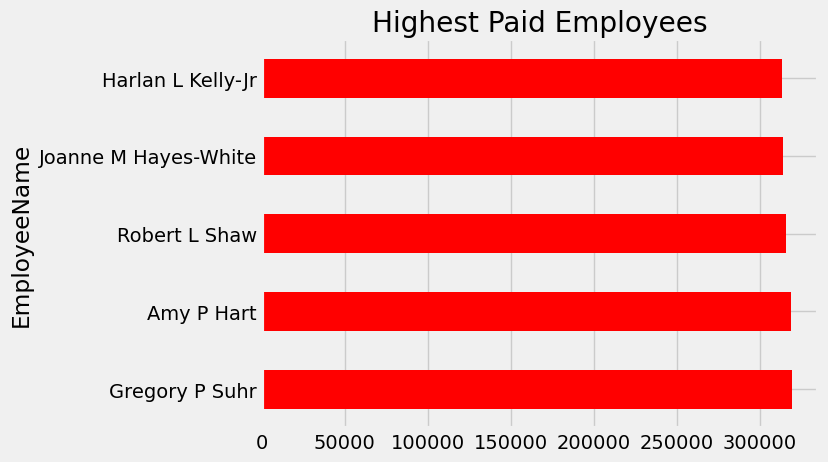

In [28]:
df['BasePay'].sort_values(ascending=False).head(5).plot(
    kind='barh',
    color='red',
    title='Highest Paid Employees'
)

<Axes: ylabel='EmployeeName'>

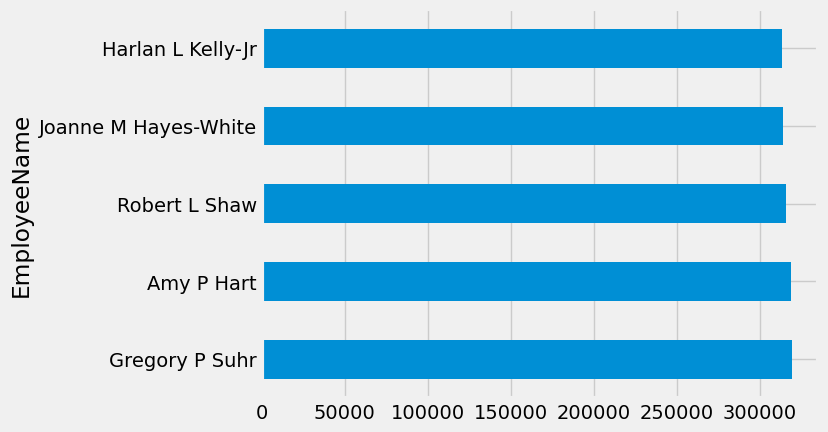

In [29]:
df['BasePay'].sort_values(ascending=False).head(5).plot.barh()

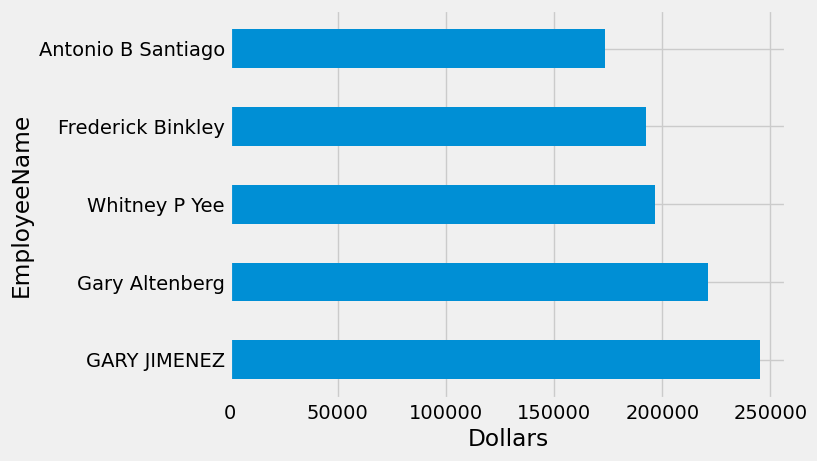

In [32]:
df['OvertimePay'].sort_values(ascending=False).head(5).plot.barh()
plt.xlabel('Dollars')
plt.show()

array([[<Axes: title={'center': 'BasePay'}>,
        <Axes: title={'center': 'OvertimePay'}>],
       [<Axes: title={'center': 'OtherPay'}>, <Axes: >]], dtype=object)

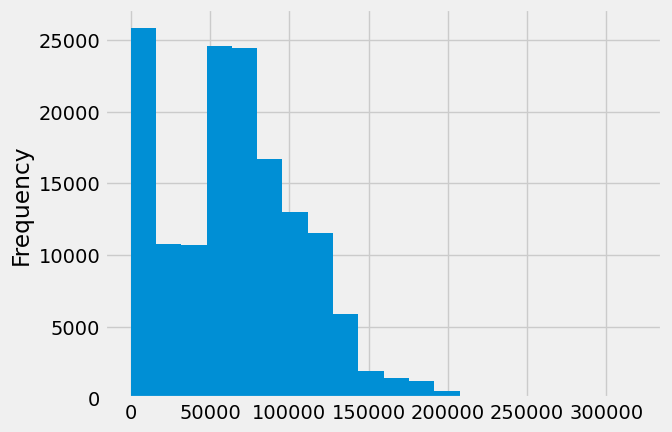

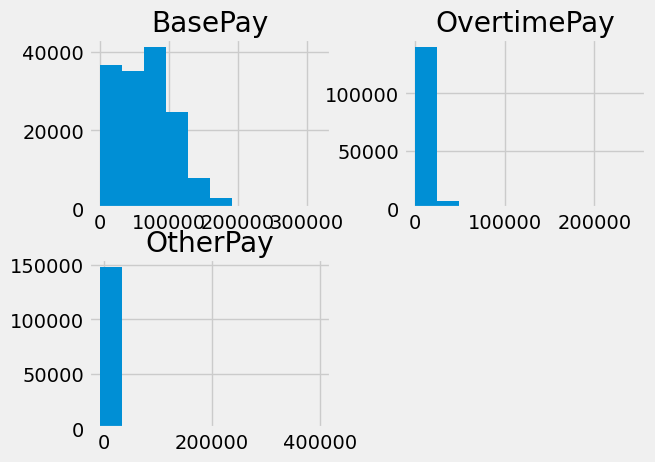

In [35]:
#Histogram
df['BasePay'].plot(kind='hist', bins=20) #.plot.hist()
df.hist() #plots subplots for every frmae content

<Axes: >

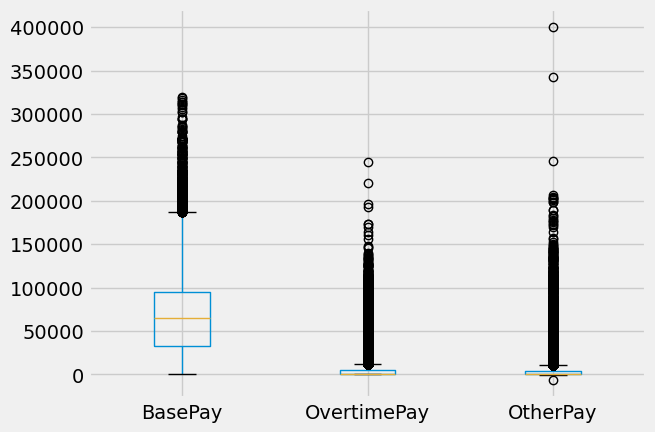

In [37]:
#BOX Plots   outliers show as dots, box shows q1-q1 line in box = median whiskers = value range
df.boxplot()

<Axes: >

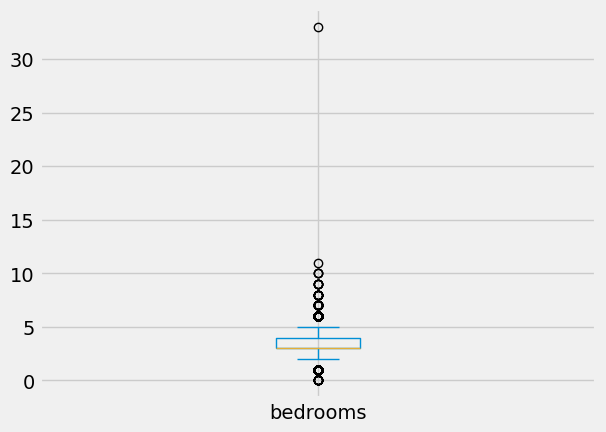

In [39]:
houses.bedrooms.plot(kind='box') #matplotlib properties can be passed  like showfliers=False

In [40]:
#Line plots

<Axes: xlabel='date_time'>

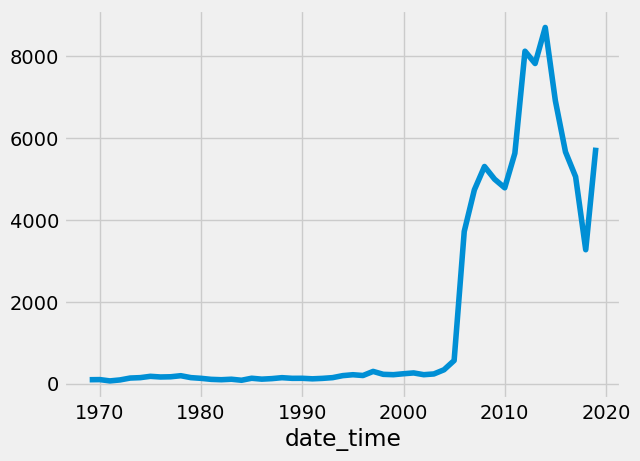

In [43]:
ufos.date_time.dt.year.value_counts().sort_index().plot(kind='line')

<Axes: >

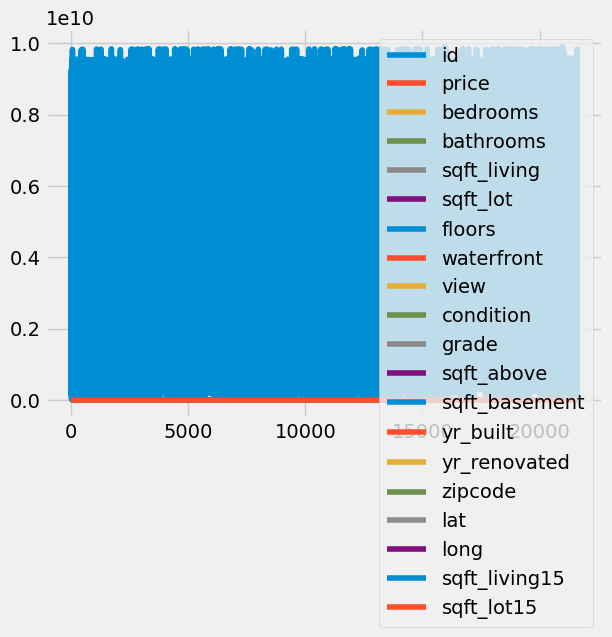

In [44]:
houses.plot.line() #x='column' y='colums' to plot just two colums  default plots index against values

<Axes: xlabel='bedrooms', ylabel='bathrooms'>

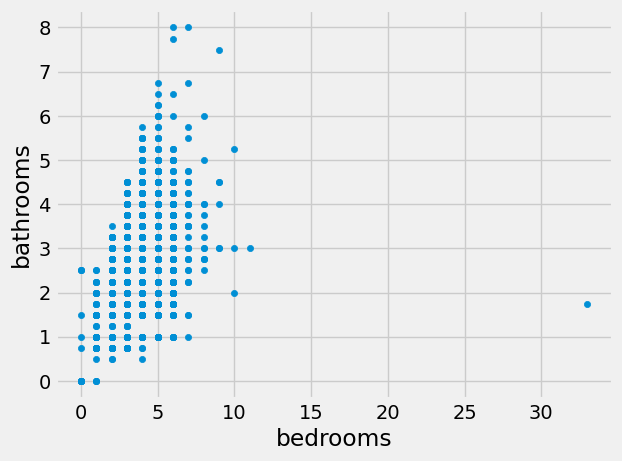

In [46]:
#Scatter plots
houses.plot.scatter(x='bedrooms', y='bathrooms') #marker=

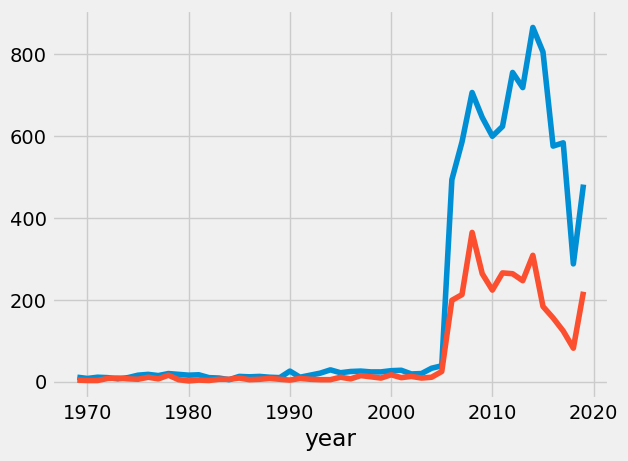

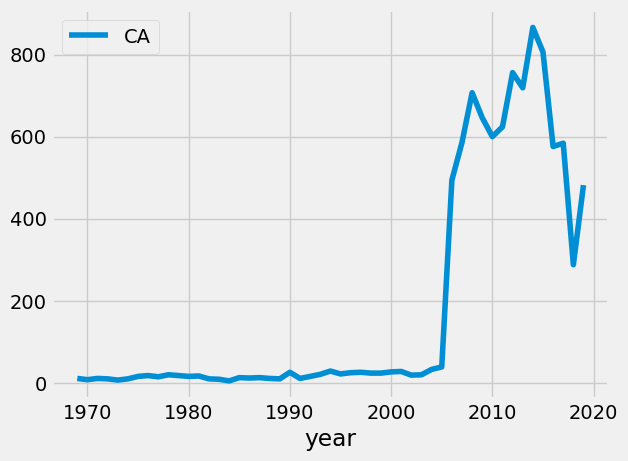

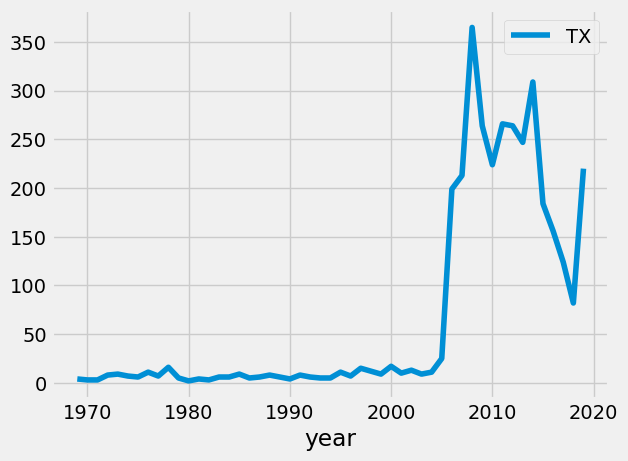

In [60]:
#Multiple plots
ufos['year'] = ufos.date_time.dt.year
ufos[ufos['state'] == 'CA'].year.value_counts().sort_index().plot()
ufos[ufos['state'] == 'TX'].year.value_counts().sort_index().plot()
plt.figure()
ufos[ufos['state'] == 'CA'].year.value_counts().sort_index().plot(label='CA')
plt.legend()
plt.figure()
ufos[ufos['state'] == 'TX'].year.value_counts().sort_index().plot(label='TX')
plt.legend()
plt.show()

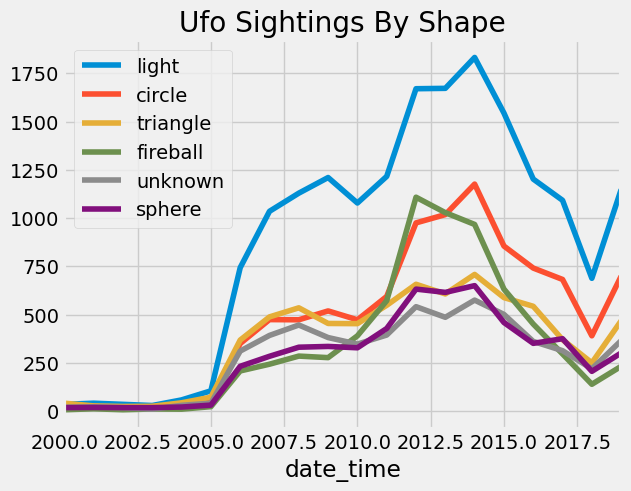

In [84]:
shapes = ufos['shape'].value_counts()
shape_list = list(shapes.index.values)
by_year = [ ufos[ufos['shape'] == shape].date_time.dt.year for shape in shape_list]
[series.value_counts().sort_index().plot(label=shape_name) for shape_name, series in zip(shape_list[:6], by_year[:6])]
plt.legend()
plt.title('Ufo Sightings By Shape')
plt.xlim(2000, 2019)
plt.show()

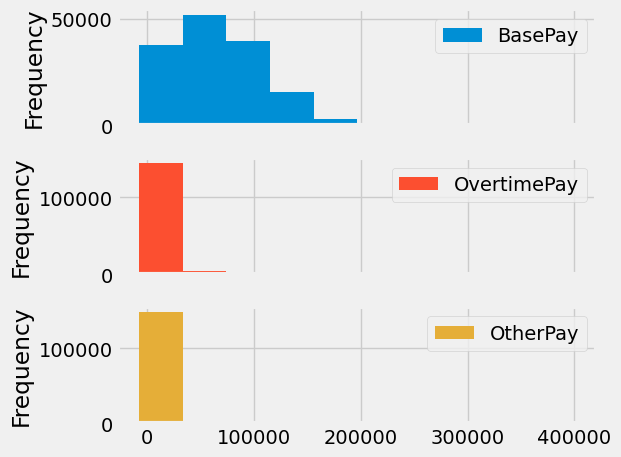

In [89]:
#Subplots
df.plot.hist(subplots=True)
plt.tight_layout()
plt.show()


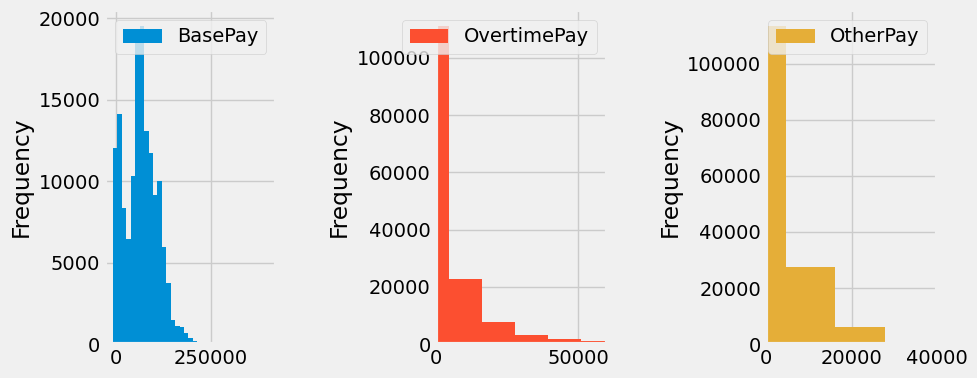

In [96]:
axes = df.plot.hist(subplots=True, sharex=False, figsize=(10, 4), layout=(1, 3), bins=35)
axes[0][2].set_xlim(0, 40000)
axes[0][1].set_xlim(0, 60000)
plt.tight_layout()
plt.show()

In [97]:
ufos['month'] = ufos.date_time.dt.month

<Axes: xlabel='year'>

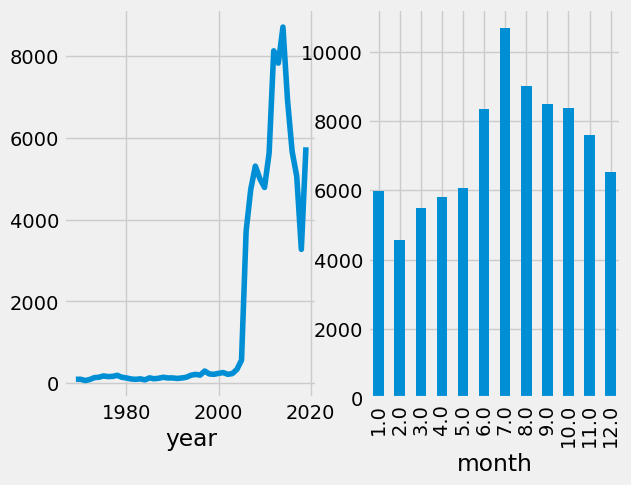

In [104]:
fig, axes = plt.subplots(1, 2)
ufos.month.value_counts().sort_index().plot(kind='bar', ax=axes[1])
ufos.year.value_counts().sort_index().plot(ax=axes[0])
#axes[0].set_title(0)

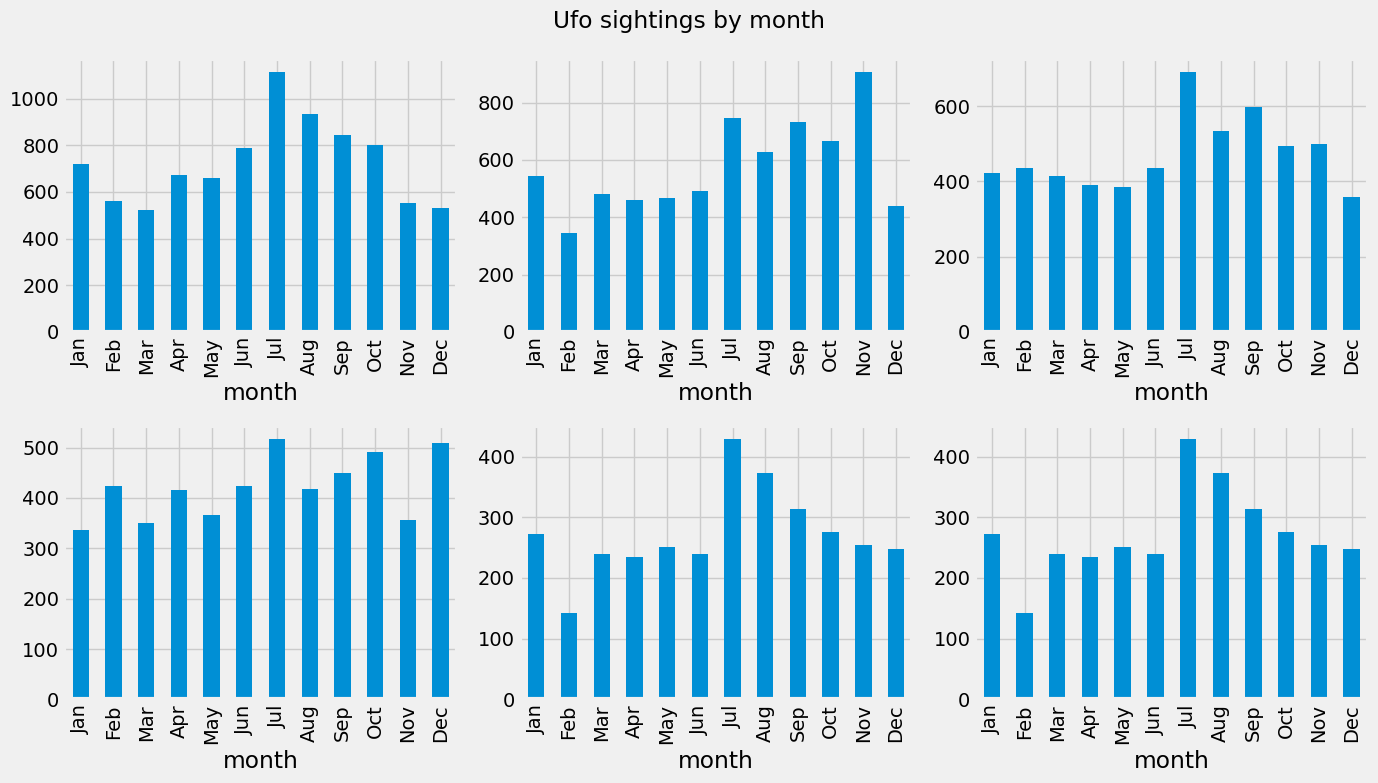

In [116]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8)) #(row, colums) two rows = [[column1-3],[column1-3]] one row = [row1]
fig.suptitle("Ufo sightings by month")
#axs[0][0].set_title('Title', color="red")
zippes = zip([0, 0, 0, 1, 1, 1], [0, 1, 2, 0, 1, 2])
years = [2014, 2015, 2016, 2017, 2018, 2018]
by_months = [ufos[ufos['year'] == year].month for year in years]
sort = [series.value_counts().sort_index().rename(months_dict) for series in by_months]
[series.plot(kind='bar', ax=axs[i][j]) for (i, j), series in zip(zippes, sort)]
plt.tight_layout()
plt.savefig('UfoByMonth')
plt.show()

In [117]:
#Exporting figures(save)
shapes = ufos['shape'].value_counts()
shape_list = list(shapes.index.values)
by_year = [ ufos[ufos['shape'] == shape].date_time.dt.year for shape in shape_list]
[series.value_counts().sort_index().plot(label=shape_name) for shape_name, series in zip(shape_list[:6], by_year[:6])]
plt.legend()
plt.title('Ufo Sightings By Shape')
plt.xlim(2000, 2019)
plt.show()
plt.savefig('Ufoshapes')